In [15]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import sys
import json
from numpy import linalg as LA
import tensorflow as tf
import getpass
ui = getpass.getuser()
if ui == 'laura':
    p = '/home/laura'
elif ui == 'lauradriscoll':
    p = '/Users/lauradriscoll/Documents'
elif ui == 'slibkind':
    p = '/Users/slibkind/Documents/'
##ADD YOUR PATH TO CODE REPOS HERE

net = 'binary_inputs'
PATH_YANGNET = os.path.join(p,'code/sophie-nets',net) 
sys.path.insert(0, PATH_YANGNET)
from task import generate_trials, rule_name, rule_index_map, rules_dict
from network import Model, get_perf, FixedPoint_Model
import tools
from sklearn.decomposition import PCA

from thesis_tools import plot_interp_pca1D, plot_interp_pca, get_xstar, get_eigenvals, get_fps_below_qthresh_idx

In [16]:
# Get the network
#WHERE IS THE NETWORK
def get_network(rule_trains):
  rnn_type = 'LeakyRNN' 
  activation = 'softplus'
  w_init = 'randgauss'
  ruleset = 'basic' # what set of tasks (look up in task.py)
  n_rnn = str(256)
  l2w = -7.0        # exponent of regularization terms
  l2h = -7.0
  l1w = 0
  l1h = 0
  lr = -7.0   # learning rate
  seed = str(0)
  rule_trains_str = '_'.join(rule_trains)
  sigma_rec = 1/20
  sigma_x = 2/20
  w_rec_coeff = .9

  net_name = 'lr'+"{:.1f}".format(-lr)+'l2_w'+"{:.1f}".format(-l2w)+'_h'+"{:.1f}".format(-l2h)
  net_name2 = '_sig_rec'+str(sigma_rec)+'_sig_x'+str(sigma_x)+'_w_rec_coeff'+"{:.1f}".format(w_rec_coeff)+'_'+rule_trains_str

  dir_specific_all = os.path.join(ruleset,rnn_type,activation,
      w_init,str(len(rule_trains))+'_tasks',str(n_rnn)+'_n_rnn',net_name+net_name2)

  return os.path.join(p,'data','sophie-nets',net,'data',dir_specific_all,str(seed))

In [17]:
dir = 'figures'

# Memory Response Task

In [18]:
ruleset = 'basic'
m = get_network(['delaygo', 'delayanti'])
q_tol_name = 'tol_q_e_6.0'


## Structure of the input and output

In [19]:
model = Model(m)
with tf.Session() as sess:
    model.restore()      # set up tf graph with model m
    var_list = model.var_list # variables learned over training
    params = [sess.run(var) for var in var_list]
    hparams = model.hp
    

Variables being optimized:
<tf.Variable 'rnn/leaky_rnn_cell/kernel:0' shape=(263, 256) dtype=float32_ref>
<tf.Variable 'rnn/leaky_rnn_cell/bias:0' shape=(256,) dtype=float32_ref>
<tf.Variable 'output/weights:0' shape=(256, 3) dtype=float32_ref>
<tf.Variable 'output/biases:0' shape=(3,) dtype=float32_ref>
INFO:tensorflow:Restoring parameters from /Users/slibkind/Documents/data/sophie-nets/binary_inputs/data/basic/LeakyRNN/softplus/randgauss/2_tasks/256_n_rnn/lr7.0l2_w7.0_h7.0_sig_rec0.05_sig_x0.1_w_rec_coeff0.9_delaygo_delayanti/0/model.ckpt
Model restored from file: /Users/slibkind/Documents/data/sophie-nets/binary_inputs/data/basic/LeakyRNN/softplus/randgauss/2_tasks/256_n_rnn/lr7.0l2_w7.0_h7.0_sig_rec0.05_sig_x0.1_w_rec_coeff0.9_delaygo_delayanti/0/model.ckpt


In [20]:
rule = 'delaygo'
trial = generate_trials(rule, hparams, mode = 'test', noise_on = False)

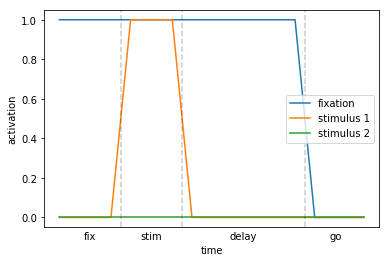

In [21]:
plt.plot(trial.x[:, 1, 0:3])
plt.legend(['fixation', 'stimulus 1', 'stimulus 2'])
plt.xlabel('time')
plt.ylabel('activation')

plt.xticks([12.5, 37.5, 75, 112.5], labels=['fix', 'stim', 'delay', 'go'])
plt.tick_params(axis='x', which='both', length=0, width=0, direction='in')


# Create dashed vertical lines
vertical_lines = [25, 50, 100]
for line in vertical_lines:
    plt.axvline(x=line, color='black', alpha=0.2, ls='dashed')

plt.savefig(os.path.join(dir, 'memory_rnn_inputs.pdf'))


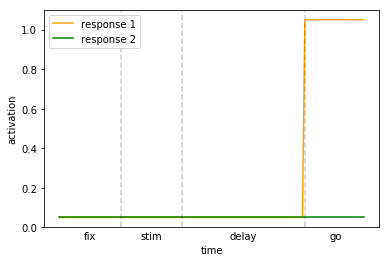

In [22]:
lines = plt.plot(trial.y[:,1,[1,2]])
lines[0].set_color('orange')
lines[1].set_color('green')
plt.legend(['response 1', 'response 2'])
plt.xlabel('time')
plt.ylabel('activation')

plt.xticks([12.5, 37.5, 75, 112.5], labels=['fix', 'stim', 'delay', 'go'])
plt.tick_params(axis='x', which='both', length=0, width=0, direction='in')


# Create dashed vertical lines
vertical_lines = [25, 50, 100]
for line in vertical_lines:
    plt.axvline(x=line, color='black', alpha=0.2, ls='dashed')


plt.savefig(os.path.join(dir, 'memory_rnn_true_outputs.pdf'))


In [23]:
rule = 'delaygo'

model = Model(m)
with tf.Session() as sess:
    model.restore()      # set up tf graph with model m
    trial = generate_trials(rule, hparams, mode='test', noise_on=False)
    feed_dict = tools.gen_feed_dict(model, trial, hparams)
    h, y_hat = sess.run([model.h, model.y_hat], feed_dict=feed_dict) #HIDDEN STATE, OUTPUT (n_TIME, n_TRIAL, n_UNIT)

Variables being optimized:
<tf.Variable 'rnn/leaky_rnn_cell/kernel:0' shape=(263, 256) dtype=float32_ref>
<tf.Variable 'rnn/leaky_rnn_cell/bias:0' shape=(256,) dtype=float32_ref>
<tf.Variable 'output/weights:0' shape=(256, 3) dtype=float32_ref>
<tf.Variable 'output/biases:0' shape=(3,) dtype=float32_ref>
INFO:tensorflow:Restoring parameters from /Users/slibkind/Documents/data/sophie-nets/binary_inputs/data/basic/LeakyRNN/softplus/randgauss/2_tasks/256_n_rnn/lr7.0l2_w7.0_h7.0_sig_rec0.05_sig_x0.1_w_rec_coeff0.9_delaygo_delayanti/0/model.ckpt
Model restored from file: /Users/slibkind/Documents/data/sophie-nets/binary_inputs/data/basic/LeakyRNN/softplus/randgauss/2_tasks/256_n_rnn/lr7.0l2_w7.0_h7.0_sig_rec0.05_sig_x0.1_w_rec_coeff0.9_delaygo_delayanti/0/model.ckpt


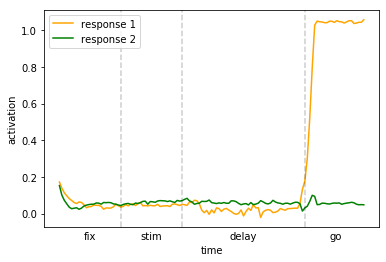

In [24]:
lines = plt.plot(y_hat[:,1,[1,2]])
lines[0].set_color('orange')
lines[1].set_color('green')

plt.legend(['response 1', 'response 2'])
plt.xlabel('time')
plt.ylabel('activation')

plt.xticks([12.5, 37.5, 75, 112.5], labels=['fix', 'stim', 'delay', 'go'])
plt.tick_params(axis='x', which='both', length=0, width=0, direction='in')


# Create dashed vertical lines
vertical_lines = [25, 50, 100]
for line in vertical_lines:
    plt.axvline(x=line, color='black', alpha=0.2, ls='dashed')

plt.savefig(os.path.join(dir, 'memory_rnn_outputs.pdf'))

## Fixed Point Structure

Show the fixed point structure at each task period

In [25]:
fps = {}
eigs = {}
names = {
  'stim 1': 'stim 1\nu = (1,1,0)', 
  'stim 2': 'stim 2\nu = (1,0,1)',
  'delay': 'fix/mem\nu = (1,0,0)',
  'go': 'go\nu = (0,0,0)'
}
q_thresh = 1e-7

fps['stim 1'] = get_xstar([1,1], ['stim1', 'delay1'], [0,0], 0, ruleset, m, q_tol_name, q_thresh=q_thresh)
fps['delay'] = get_xstar([1,1], ['stim1', 'delay1'], [0,0], 20, ruleset, m, q_tol_name, q_thresh=q_thresh)
fps['stim 2'] = get_xstar([1,1], ['delay1', 'stim1'], [1,1], 20, ruleset, m, q_tol_name, q_thresh=q_thresh)
fps['go'] = get_xstar([1,1], ['delay1', 'go1'], [0,0], 20, ruleset, m, q_tol_name, q_thresh=q_thresh)

eigs['stim 1'] = get_eigenvals([1,1], ['stim1', 'delay1'], [0,0], 0, ruleset, m, q_tol_name, q_thresh=q_thresh)
eigs['delay'] = get_eigenvals([1,1], ['stim1', 'delay1'], [0,0], 20, ruleset, m, q_tol_name, q_thresh=q_thresh)
eigs['stim 2'] = get_eigenvals([1,1], ['delay1', 'stim1'], [1,1], 20, ruleset, m, q_tol_name, q_thresh=q_thresh)
eigs['go'] = get_eigenvals([1,1], ['delay1', 'go1'], [0,0], 20, ruleset, m, q_tol_name, q_thresh=q_thresh)
eigs['fix'] = get_eigenvals([1,1], ['fix1', 'stim1'], [0,0], 0, ruleset, m, q_tol_name, q_thresh=q_thresh)


In [26]:
# Concatenate arrays from all keys in fps
all_points = np.concatenate(list(fps.values()), axis=0)

# Perform PCA on all_points
pca = PCA(n_components=2)  # Set the number of components you want to keep
transformed_data = pca.fit_transform(all_points)

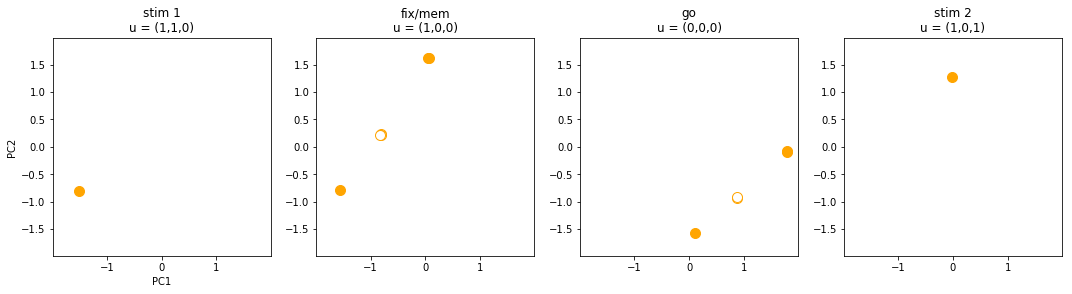

In [27]:
extra_padding = 0.2  # Adjust the value of extra_padding as needed
s = 100
fig, axes = plt.subplots(1, len(fps), figsize=(15, 5))

max_abs_value = max(np.abs(transformed_data).max() for transformed_data in pca.transform(all_points))

c = 'orange'

for idx, k in enumerate(fps):
    ax = axes[idx]
    transformed_data = pca.transform(fps[k])
    
    for i in range(len(transformed_data)):
        if np.abs(np.max(eigs[k][i])) > 1:
          facecolors = 'w'
        else:
          facecolors = c
            
        ax.scatter(transformed_data[i][0], transformed_data[i][1],
                   s = s, edgecolors=c, facecolors=facecolors)
    
    ax.set_xlim(-max_abs_value - extra_padding, max_abs_value + extra_padding)
    ax.set_ylim(-max_abs_value - extra_padding, max_abs_value + extra_padding)
    ax.set_aspect('equal')  # Ensure equal scaling for both axes
    ax.set_title(names[k], fontsize=12)
    ax.tick_params(axis='both', which='both')

    if idx == 0:
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')

plt.tight_layout()

plt.savefig(os.path.join(dir, 'fps-for-periods.pdf'))

Show the interpolated fixed point structure over a sample run

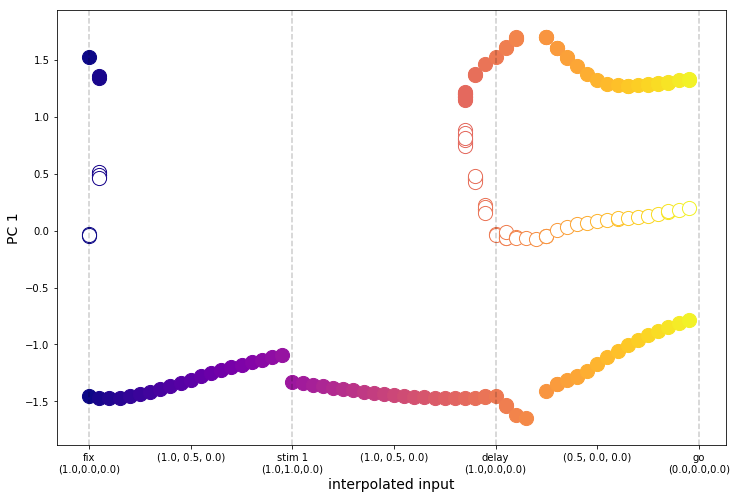

In [40]:
m = get_network(['delaygo', 'delayanti'])
ri_set = [1, 1, 1, 1]
epoch_list = ['fix1', 'stim1', 'delay1', 'go1']
trial_num = [0,0,0,0]
q_thresh = 1e-7

ax = plot_interp_pca1D(ri_set, epoch_list, trial_num, ruleset, m, q_tol_name, q_thresh = q_thresh)

# Create dashed vertical lines
vertical_lines = [0,1,2,3]
for line in vertical_lines:
    plt.axvline(x=line, color='black', alpha=0.2, ls='dashed')

plt.xticks([0,.5,1,1.5,2,2.5,3], 
           labels=['fix\n(1.0,0.0,0.0)', '(1.0, 0.5, 0.0)', 'stim 1\n(1.0,1.0,0.0)','(1.0, 0.5, 0.0)', 'delay\n(1.0,0.0,0.0)', '(0.5, 0.0, 0.0)','go\n(0.0,0.0,0.0)'], rotation=0)

plt.xlabel('interpolated input', fontsize = 14)
plt.ylabel('PC 1', fontsize = 14)

plt.savefig(os.path.join(dir, 'fps-fix-stim-delay-go.pdf'))

Show the fixed point structure interpolating between `stim 1`, `delay`, and `stim 2` periods

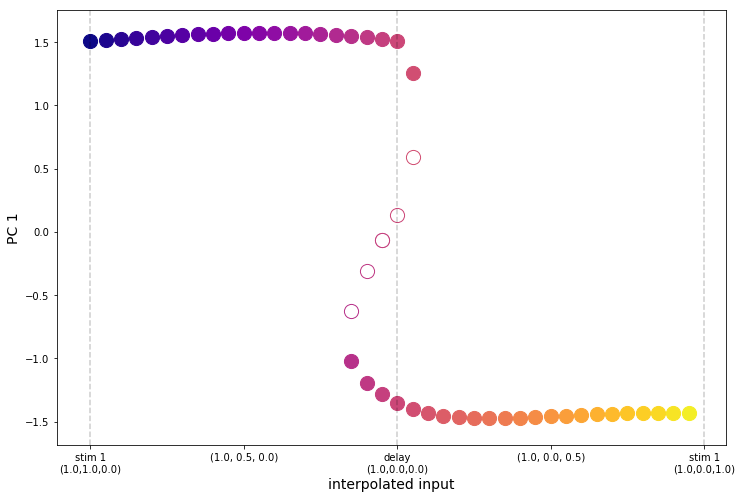

In [41]:
m = get_network(['delaygo', 'delayanti'])
ri_set = [1, 1, 1]
epoch_list = ['stim1', 'delay1', 'stim1']
trial_num = [0,0,1] 

ax = plot_interp_pca1D(ri_set, epoch_list, trial_num, ruleset, m, q_tol_name, q_thresh = 1e-10)

# Create dashed vertical lines
vertical_lines = [0,1,2]
for line in vertical_lines:
    plt.axvline(x=line, color='black', alpha=0.2, ls='dashed')

plt.xticks([0,.5,1,1.5,2], 
           labels=['stim 1\n(1.0,1.0,0.0)','(1.0, 0.5, 0.0)', 'delay\n(1.0,0.0,0.0)', '(1.0, 0.0, 0.5)','stim 1\n(1.0,0.0,1.0)'], rotation=0)

plt.xlabel('interpolated input', fontsize = 14)
plt.ylabel('PC 1', fontsize =14)

plt.savefig(os.path.join(dir, 'fps-stim1-delay-stim2.pdf'))

## Zigzag persistence